# Classification and Clustering

**Objectives:**
- Preprocess real-world data for machine learning (encoding, variable selection)
- Train classification models (Logistic Regression, K-Nearest Neighbors, Decision Trees)
- Evaluate classifiers using accuracy and confusion matrices
- Compare models and validate on held-out data
- Visualise decision tree rules and feature importances
- Apply K-Means clustering and relate clusters to labels

## Part 1: Predicting the Credit Score

The two CSV files (source: [Kaggle](https://www.kaggle.com/datasets/clkmuhammed/creditscoreclassification?select=train.csv)) contain data about clients of a global finance company.

The goal is to predict a client's credit score category (**Good / Standard / Poor**) using available characteristics such as income, debt, payment behaviour, and other financial indicators.



### Step 1: Import the Data

We load two separate CSV files:
- **`train.csv`** — the main dataset used to build and evaluate our models
- **`test.csv`** — a completely separate file kept aside as a **validation set**

We do **not** look at the validation set until the very end.
Keeping it separate from the start ensures a truly unbiased final evaluation.

In [1]:
import pandas
dataset = pandas.read_csv("train.csv")
validation = pandas.read_csv("test.csv")

### Step 2: Explore the Data

Before building any model, we explore the data to understand its structure:
- What columns (features) are available?
- What does the target variable look like?
- Are there any obvious issues (irrelevant columns, wrong data types)?

We did this last week

### Steps 3 and 4: Define then encode the target variables and categorical features




In [2]:
dataset['Credit_Score'].unique()

from sklearn.preprocessing import LabelEncoder

cle = LabelEncoder()
dataset['Credit_Score'] = cle.fit_transform(dataset['Credit_Score'])


# Check the mapping: which number corresponds to which label?
score_categories = cle.inverse_transform([0, 1, 2])
print("0 =", score_categories[0], "| 1 =", score_categories[1], "| 2 =", score_categories[2])

#from sklearn.preprocessing import LabelEncoder as le

dataset['Payment_of_Min_Amount'] = cle.fit_transform(dataset['Payment_of_Min_Amount'])
dataset['Payment_Behaviour'] = cle.fit_transform(dataset['Payment_Behaviour'])
dataset['Occupation'] = cle.fit_transform(dataset['Occupation'])
dataset['Type_of_Loan'] = cle.fit_transform(dataset['Type_of_Loan'])
dataset['Credit_Mix'] = cle.fit_transform(dataset['Credit_Mix'])

# Drop the Name column — it has no predictive value
dataset = dataset.drop(columns=["Name"], errors='ignore')

# dataset.head()

0 = Good | 1 = Poor | 2 = Standard


### Step 5: Visualize the Data



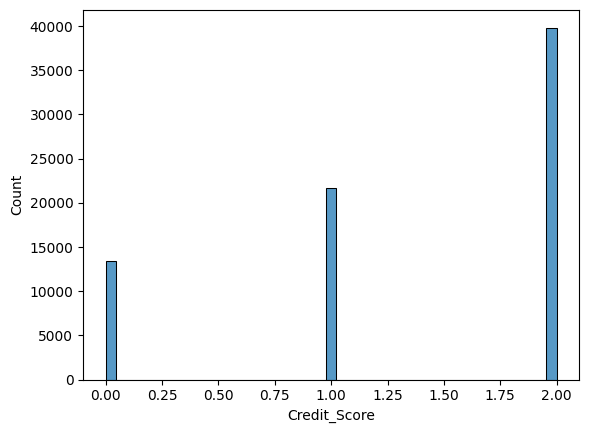

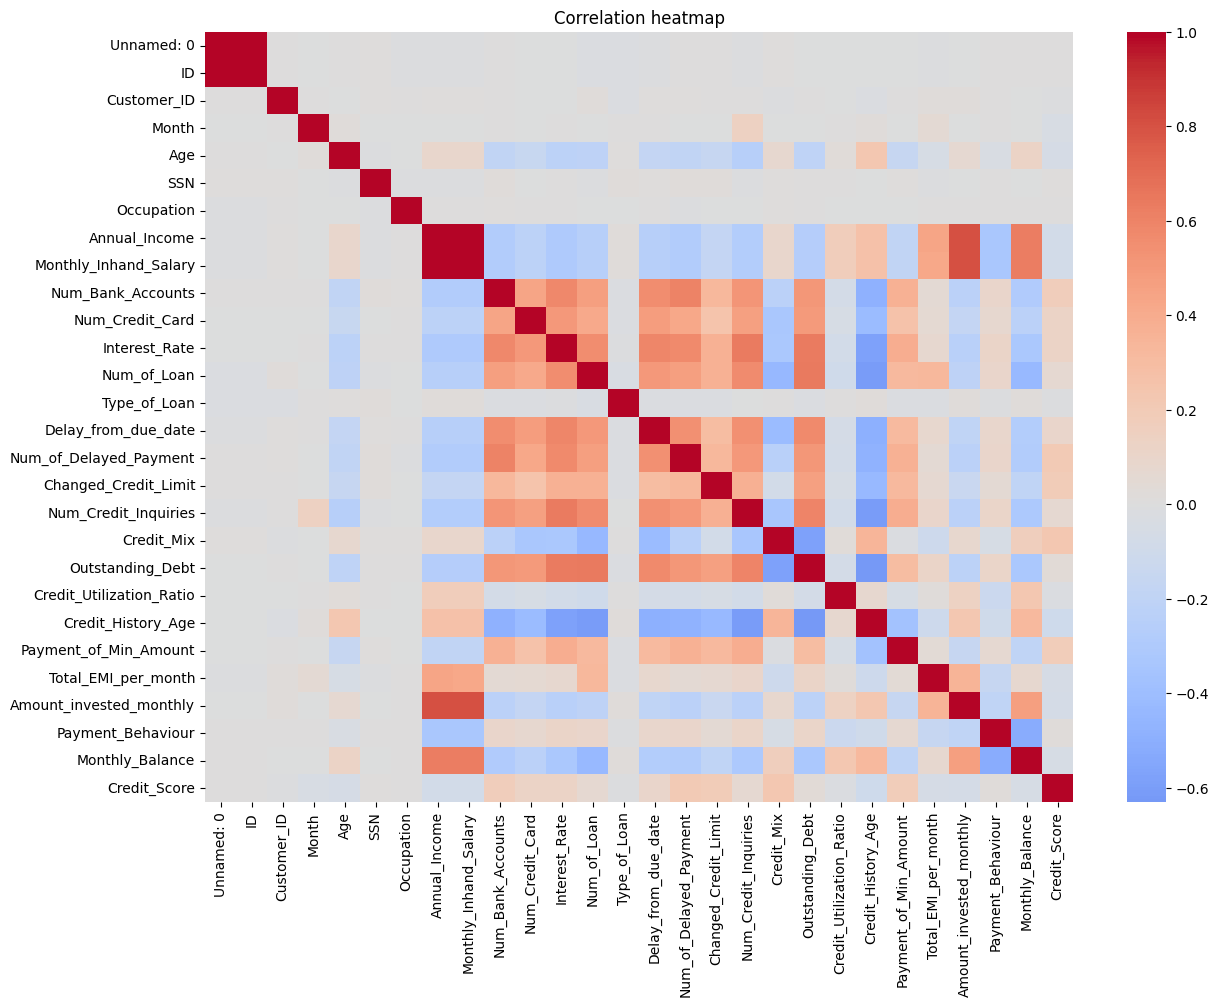

In [3]:
import seaborn as sns
sns.histplot(dataset['Credit_Score'])

import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
#sns.heatmap(dataset.corr(numeric_only=True))
# Uncomment the line below to see the heatmap with better color maps
sns.heatmap(dataset.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()

---
### Step 6: Split Into Training and Test Sets

In [4]:
import sklearn.model_selection

df_train, df_test = sklearn.model_selection.train_test_split(
    dataset, test_size=0.25, random_state=243
)

### Step 7: Select Features and Prepare X / Y


In [5]:
variables = [
    'Changed_Credit_Limit',
    'Payment_of_Min_Amount',
    'Credit_Mix',
    'Delay_from_due_date',
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Age',
    'Monthly_Balance',
    'Num_of_Delayed_Payment',
    'Outstanding_Debt',
    'Payment_Behaviour',
    'Credit_History_Age',
    'Num_Bank_Accounts',
    'Credit_Utilization_Ratio'
]

# Features and labels for the training set
X = df_train[variables]
Y = df_train['Credit_Score']

# Features and labels for the test set
X_test = df_test[variables]
Y_test = df_test['Credit_Score']

---
## Step 8: Logistic Regression

In [6]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X, Y)

c:\Users\ezgio\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Accuracy = proportion of correctly predicted observations.

$$
\text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of observations}}
$$

In sklearn classification models:

```python
model.score(X_test, Y_test)

In [7]:
print("Training accuracy:", model_lr.score(X, Y))
print("Test accuracy:    ", model_lr.score(X_test, Y_test))

Training accuracy: 0.6024177777777778
Test accuracy:     0.6014933333333333


---
## Step 9: Evaluating the Model — The Confusion Matrix




In [8]:
actual = Y_test
predicted = model_lr.predict(X_test)

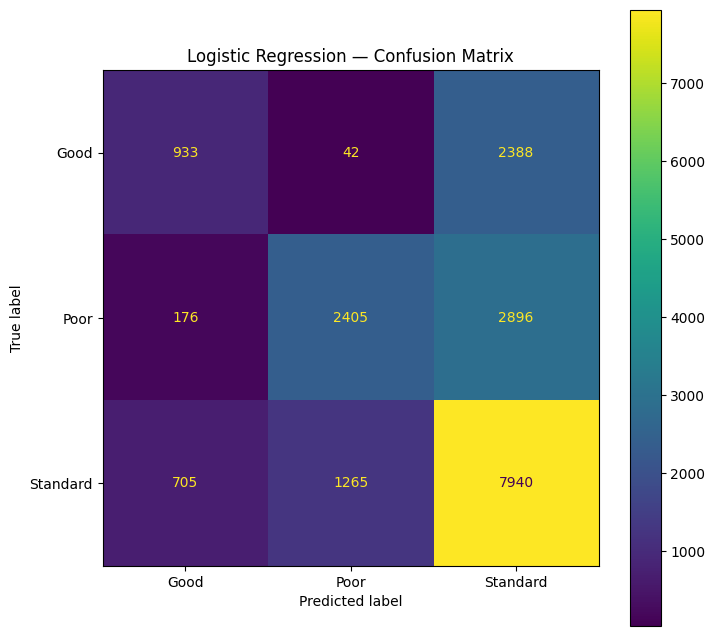

In [9]:
from sklearn import metrics

confusion_matrix = metrics.confusion_matrix(actual, predicted)
confusion_matrix

cm_display_lr = metrics.ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix, display_labels=score_categories
)

fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(False)
cm_display_lr.plot(ax=ax)
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

### Normalised Confusion Matrix


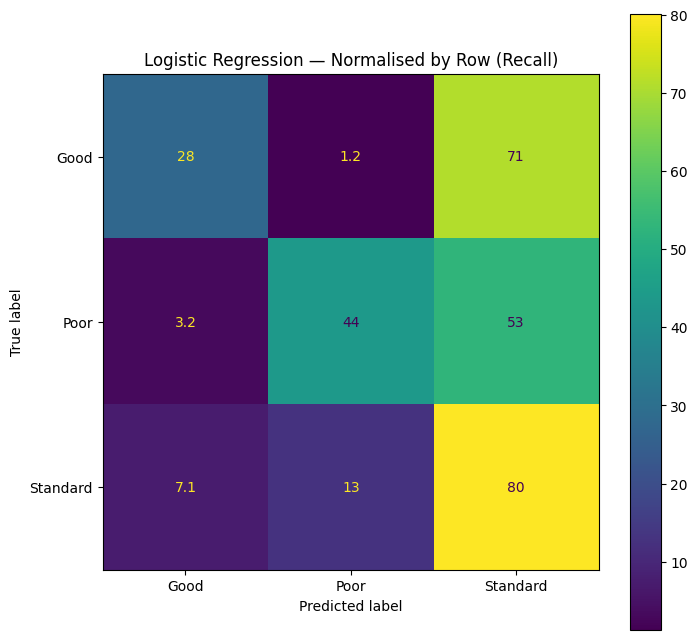

In [10]:
# Normalize by row (recall): what % of each actual category was correctly detected?
cm_by_row = confusion_matrix / confusion_matrix.sum(axis=1)[:, None] * 100
cm_by_row

cm_display_row = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm_by_row, display_labels=score_categories
)

fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(False)
cm_display_row.plot(ax=ax)
plt.title("Logistic Regression — Normalised by Row (Recall)")
plt.show()

> **Interpretation (recall):** Look at the diagonal values. Each diagonal cell shows the
> percentage of clients in that category who were correctly identified. For example,
> if the "Poor" row shows 44% on the diagonal, it means only 44% of actual "Poor"
> clients were correctly detected — the other 56% were misclassified as Standard or Good.

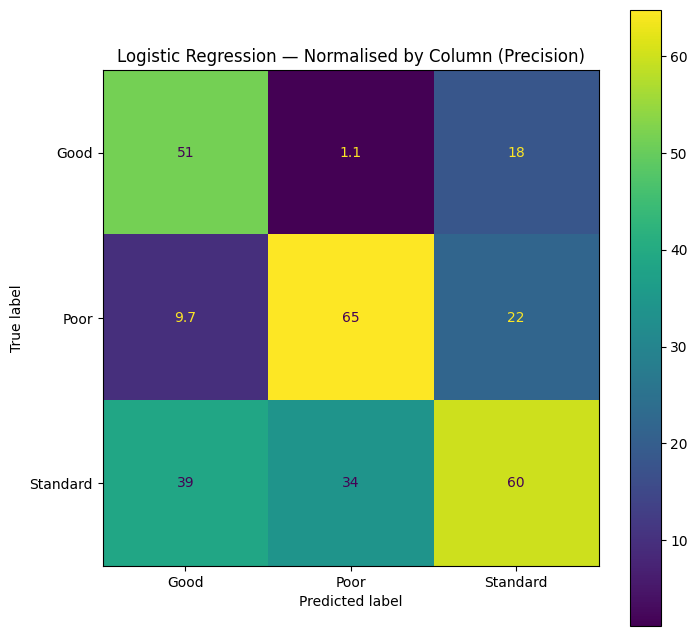

In [11]:
# Normalize by column (precision): of all predictions for a category, how many were correct?
cm_by_col = confusion_matrix / confusion_matrix.sum(axis=0)[None, :] * 100
cm_by_col

cm_display_col = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm_by_col, display_labels=score_categories
)

fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(False)
cm_display_col.plot(ax=ax)
plt.title("Logistic Regression — Normalised by Column (Precision)")
plt.show()

> **Interpretation (precision):** Each diagonal cell shows the percentage of *predicted*
> labels that were actually correct. For example, if the "Poor" column shows 65% on the
> diagonal, it means that of all clients the model flagged as "Poor", only 65% actually were —
> the other 35% were false alarms (clients wrongly classified as Poor).

---
## Step 10: K-Nearest Neighbors (KNN)


In [12]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier()
model_knn.fit(X, Y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [14]:
actual = Y_test
predicted = model_knn.predict(X_test)

print("Training accuracy:", model_knn.score(X, Y))
print("Test accuracy:    ", model_knn.score(X_test, Y_test))

Training accuracy: 0.8265955555555555
Test accuracy:     0.7259733333333334


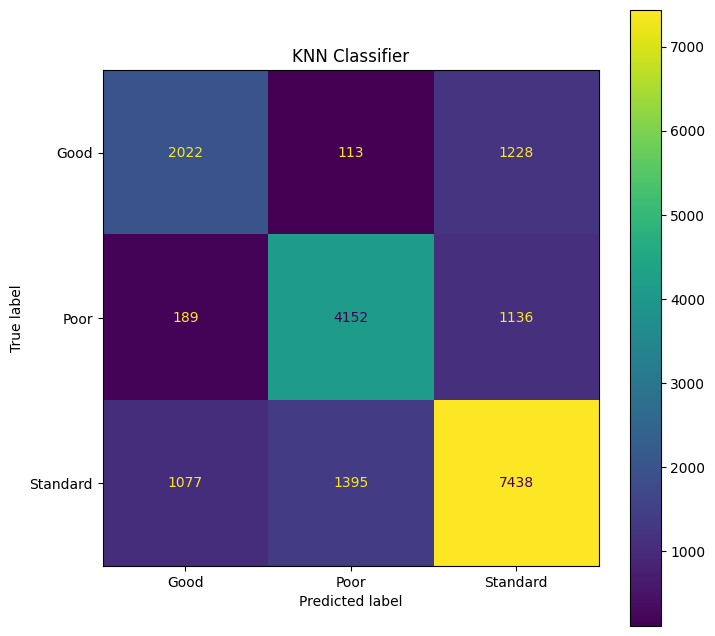

In [15]:
confusion_matrix_knn = metrics.confusion_matrix(actual, predicted)
cm_display_knn = metrics.ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_knn, display_labels=score_categories
)

fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(False)
cm_display_knn.plot(ax=ax)
plt.title("KNN Classifier")
plt.show()

#### Side-by-Side Comparison


As discussed above, raw confusion matrices show **counts**, but counts can be misleading when classes have very different sizes. It is often more informative to look at **normalised confusion matrices**, which show **percentages** instead of counts.

Here we normalise **by row**, so each row sums to 1.  Remember that this allows us to evaluate **recall**: among observations truly belonging to a class, what proportion is correctly predicted?

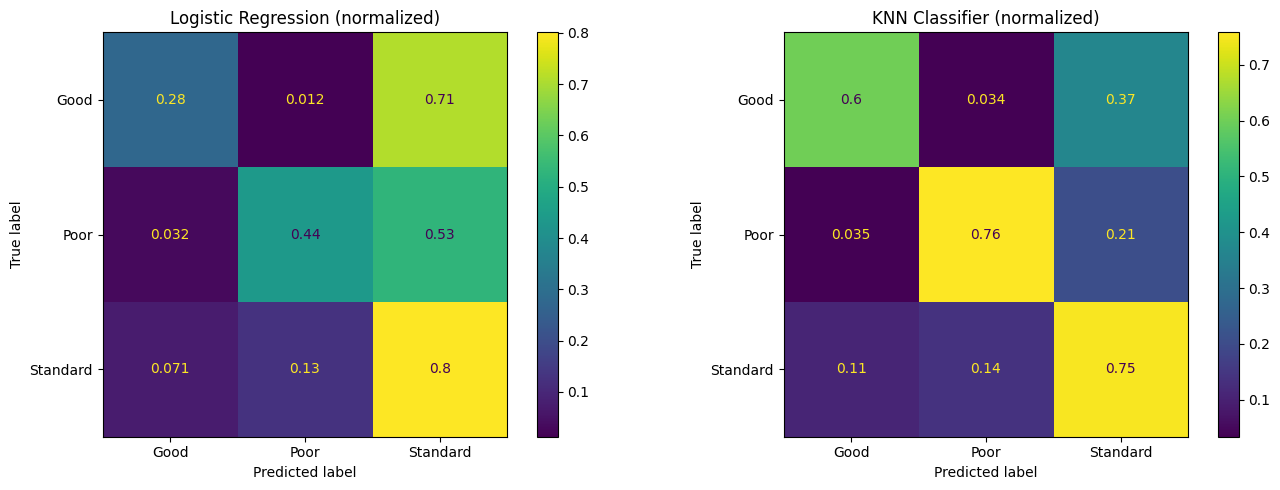

In [17]:
from sklearn import metrics
import matplotlib.pyplot as plt

# Logistic Regression confusion matrix
predicted_lr = model_lr.predict(X_test)
confusion_matrix_lr = metrics.confusion_matrix(Y_test, predicted_lr, normalize="true")
cm_display_lr = metrics.ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_lr,
    display_labels=score_categories
)

# KNN confusion matrix
predicted_knn = model_knn.predict(X_test)
confusion_matrix_knn = metrics.confusion_matrix(Y_test, predicted_knn, normalize="true")
cm_display_knn = metrics.ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_knn,
    display_labels=score_categories
)

# Side-by-side plot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

ax = axes[0]
ax.grid(False)
cm_display_lr.plot(ax=ax)
ax.set_title("Logistic Regression (normalized)")

ax = axes[1]
ax.grid(False)
cm_display_knn.plot(ax=ax)
ax.set_title("KNN Classifier (normalized)")

plt.tight_layout()
plt.show()

---
## Step 11: Decision Trees


A **decision tree** classifies observations by asking a sequence of **yes/no questions** about the input features.  Each question splits the data into two smaller groups, exactly like the branches of a tree.

**Example — classifying a new bank client:**

```
Is Credit_Mix good?
├── Yes  →  Is Delay_from_due_date > 10?
│           ├── Yes  →  Standard
│           └── No   →  Good
└── No   →  Is Outstanding_Debt > 1500?
            ├── Yes  →  Poor
            └── No   →  Standard
```

The model learns **which questions to ask** and **where to draw the threshold** by finding the splits that best separate the classes in the training data.


At each node, the algorithm looks for the split that creates the **purest**  groups where most observations belong to the same class.

One of the most common purity measures is the **Gini impurity**:

$$
\text{Gini} = 1 - \sum_{k} p_k^2
$$

where $p_k$ is the proportion of class $k$ in a node.  

A node is **perfectly pure** (Gini = 0) when it contains only one class.  A node is **maximally impure** when all classes are equally represented.




### Problem of overfitting

Left unconstrained, a decision tree keeps splitting until every leaf contains exactly one observation: It memorises the training data perfectly but generalises poorly to new data.  We control this with **`max_depth`**: the maximum number of levels the tree is allowed to grow.

| `max_depth` | Effect |
|:--|:--|
| Very large (or `None`) | Deep tree, very flexible, tends to overfit |
| Small (e.g., 4–6) | Shallow tree, simpler rules, better generalisation |

We use `max_depth=5` here as a reasonable starting point.



**Key advantage of decision trees:** they produce human-readable rules that can be explained directly to a client or a manager  

In [22]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
model_dt.fit(X, Y)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Just like before, training accuracy versus test accuracy.

In [23]:
print("Training accuracy:", model_dt.score(X, Y))
print("Test accuracy:    ", model_dt.score(X_test, Y_test))

Training accuracy: 0.6848
Test accuracy:     0.6811733333333333


---
### Visualizing the Tree

One of the biggest strengths of decision trees is **interpretability**: you can literally read the rules the model learned.

Here we plot the first **3 levels** of the tree.  Each node shows:
- the **splitting rule** (e.g., `Credit_Mix <= 0.5`)
- the **Gini impurity** of that node
- the **number of samples** reaching that node
- the **predicted class** (majority class at that node)

Darker colours indicate purer nodes (one class dominates).

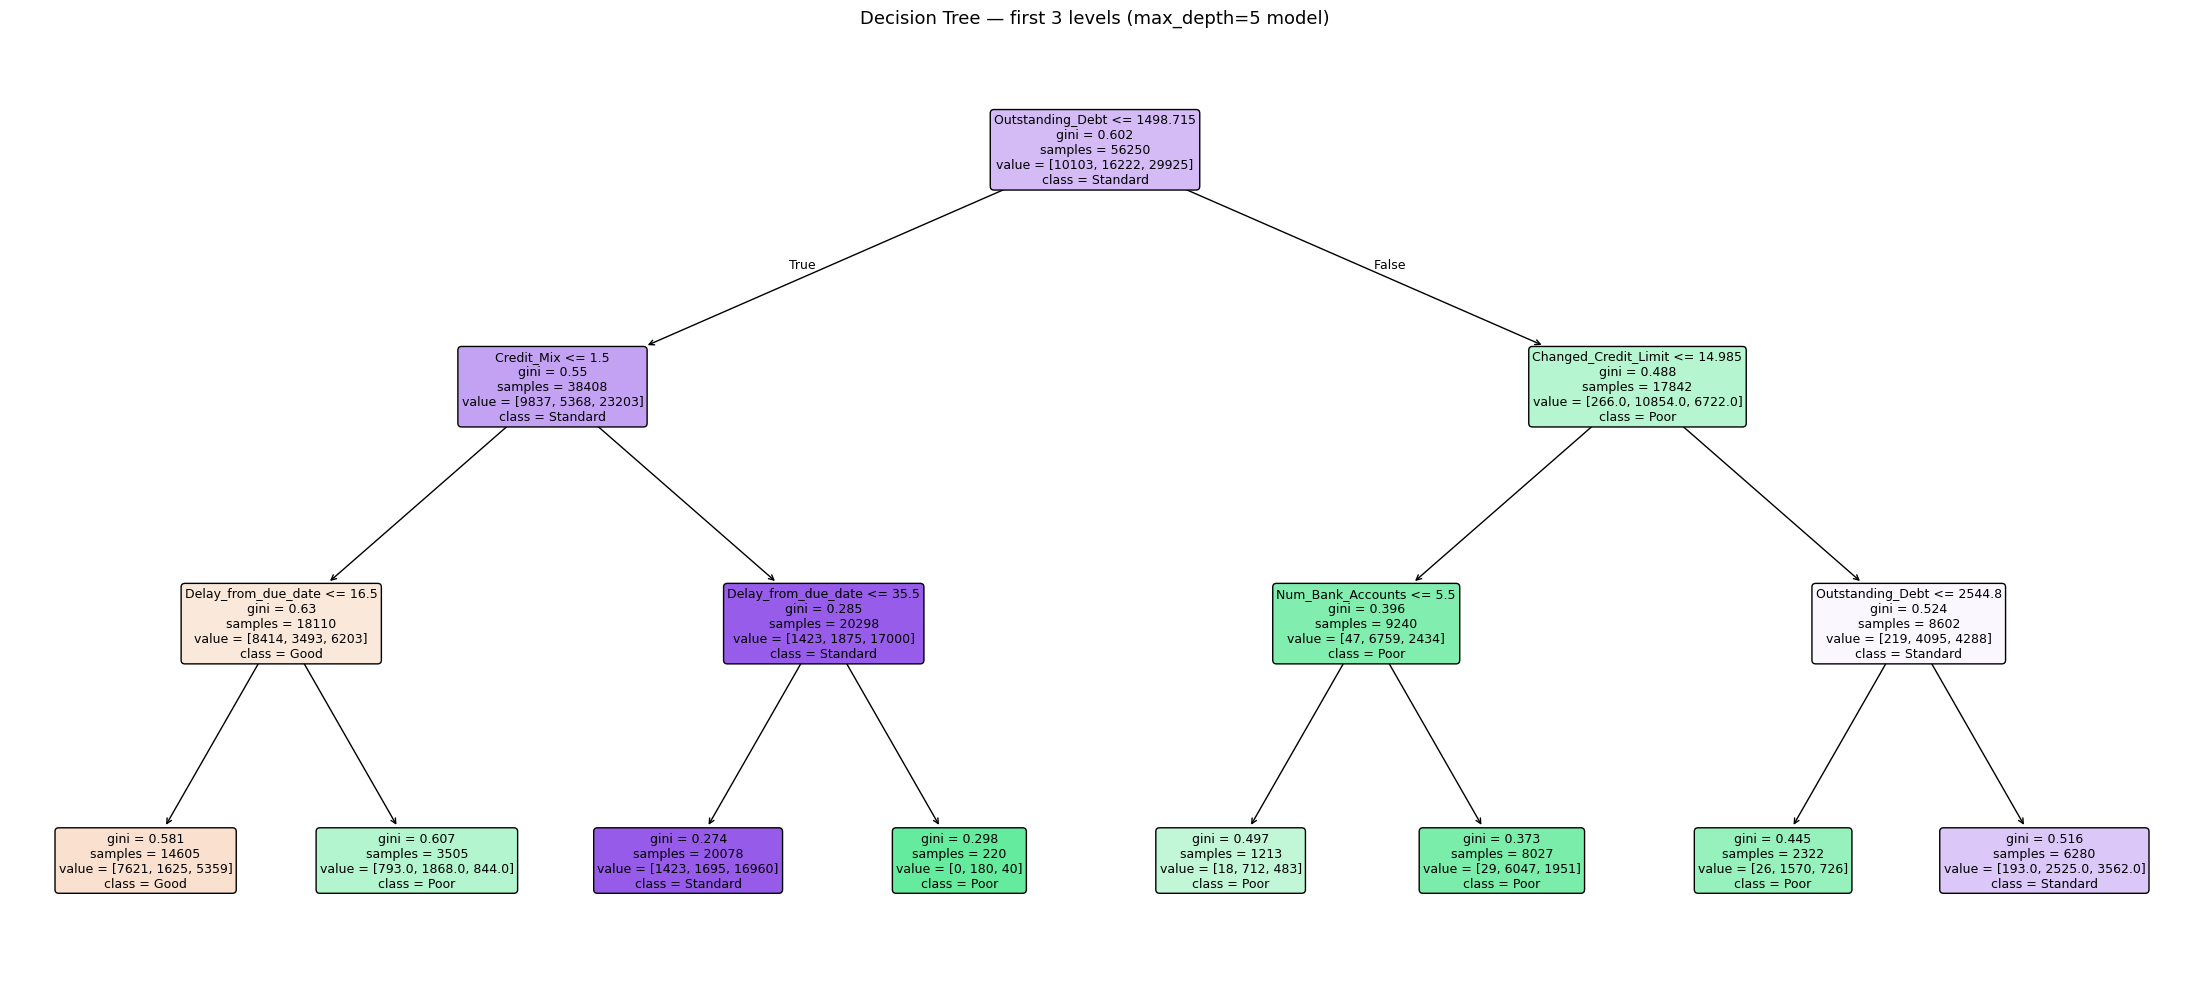

In [24]:
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 10))
plot_tree(
    model_dt,
    feature_names=variables,
    class_names=score_categories,
    filled=True,
    rounded=True,
    max_depth=3,   # show first 3 levels only — tree may be deeper
    fontsize=9
)
plt.title("Decision Tree — first 3 levels (max_depth=5 model)", fontsize=13)
plt.tight_layout()
plt.show()

### Feature Importances

Every time the tree makes a split, it reduces impurity.  **Feature importance** measures the total impurity reduction attributed to each feature across all splits.  Features that are never used get an importance of 0.

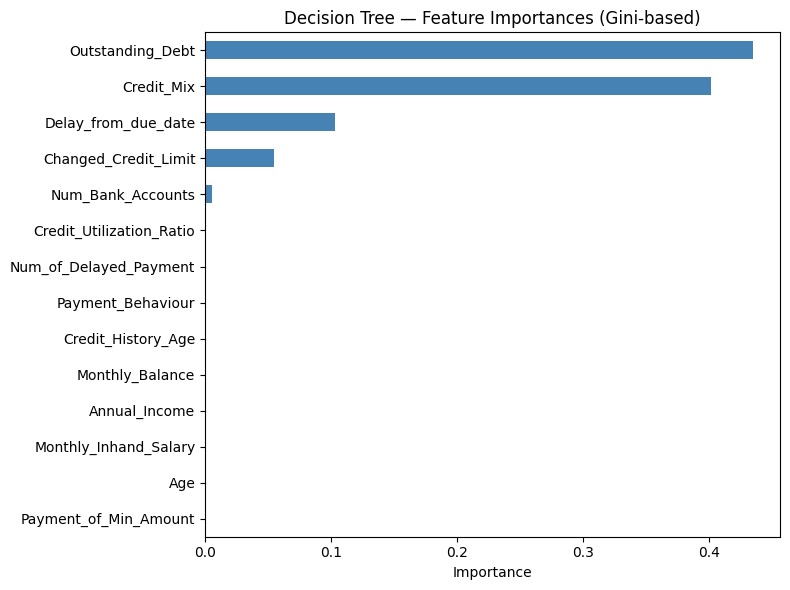

In [25]:
importances = pandas.Series(
    model_dt.feature_importances_, index=variables
).sort_values(ascending=True)

importances.plot.barh(figsize=(8, 6), color="steelblue")
plt.title("Decision Tree — Feature Importances (Gini-based)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Confusion Matrix

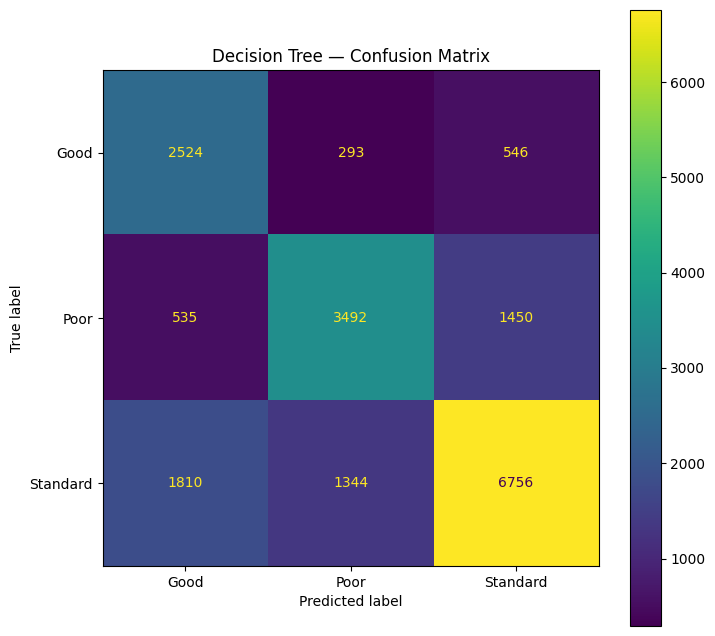

In [26]:
predicted_dt = model_dt.predict(X_test)
confusion_matrix_dt = metrics.confusion_matrix(Y_test, predicted_dt)

cm_display_dt = metrics.ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_dt, display_labels=score_categories
)

fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(False)
cm_display_dt.plot(ax=ax)
plt.title("Decision Tree — Confusion Matrix")
plt.show()

### Three-Way Comparison: Logistic Regression vs KNN vs Decision Tree

Normalised by row (recall) so we can compare how well each model detects each credit score category.

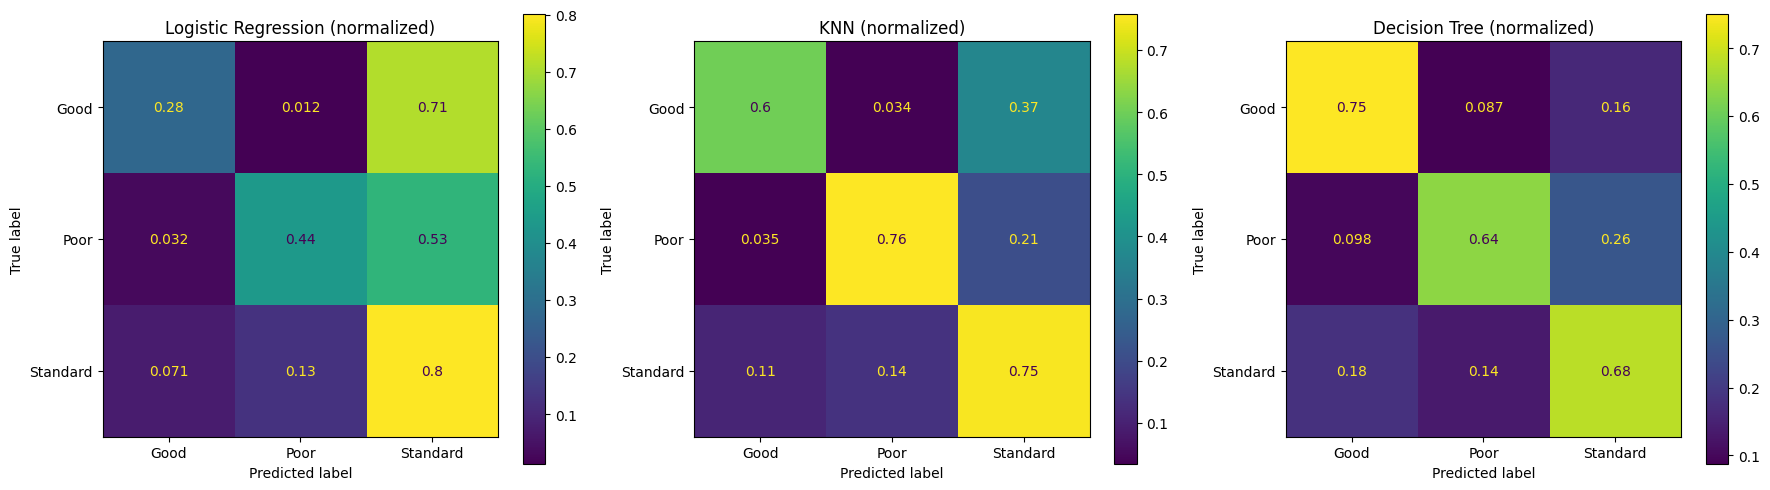

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model, name in zip(
    axes,
    [model_lr, model_knn, model_dt],
    ["Logistic Regression", "KNN", "Decision Tree"]
):
    pred = model.predict(X_test)
    cm = metrics.confusion_matrix(Y_test, pred, normalize="true")
    cm_disp = metrics.ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=score_categories
    )
    ax.grid(False)
    cm_disp.plot(ax=ax)
    ax.set_title(f"{name} (normalized)")

plt.tight_layout()
plt.show()

---
### Step 12: Validate on the Held-Out Set


**Why?** We chose KNN because it performed better *on the test set*. But since the test
set influenced our model selection decision, it is no longer a truly independent evaluation.
The **validation set** (`test.csv`) — which we have never touched — gives us an unbiased
estimate of real-world performance.

We must preprocess the validation set in exactly the same way as the training data.

In [29]:
from sklearn.preprocessing import LabelEncoder

validation['Payment_of_Min_Amount'] = LabelEncoder().fit_transform(validation['Payment_of_Min_Amount'])
validation['Payment_Behaviour'] = LabelEncoder().fit_transform(validation['Payment_Behaviour'])
validation['Occupation'] = LabelEncoder().fit_transform(validation['Occupation'])
validation['Type_of_Loan'] = LabelEncoder().fit_transform(validation['Type_of_Loan'])
validation['Credit_Mix'] = LabelEncoder().fit_transform(validation['Credit_Mix'])
validation['Credit_Score'] = LabelEncoder().fit_transform(validation['Credit_Score'])

In [33]:
X_valid = validation[variables]
Y_valid = validation['Credit_Score']

actual_valid = Y_valid
predicted_valid = model_knn.predict(X_valid)

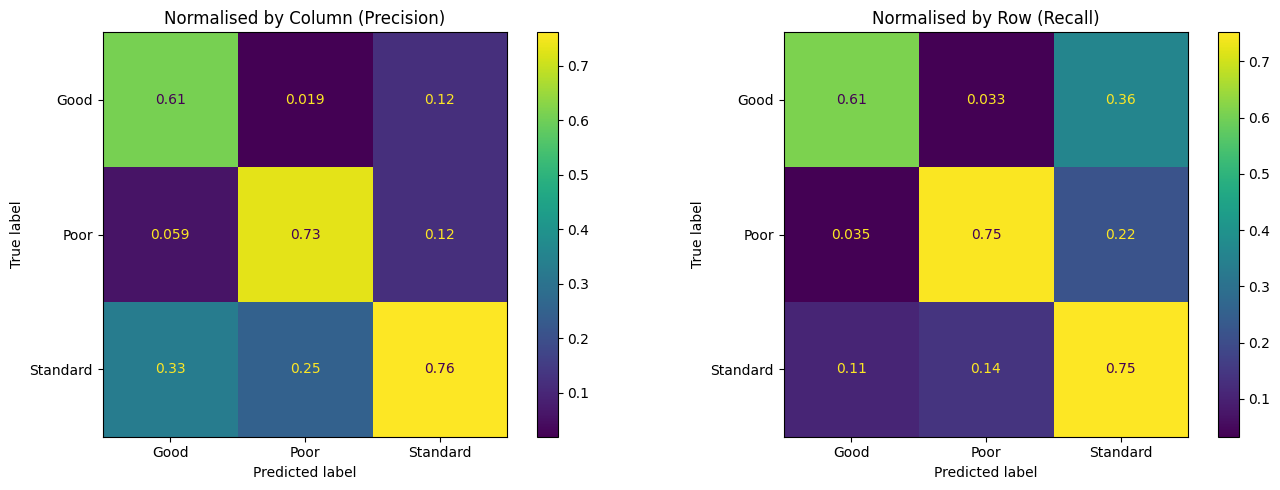

In [34]:
confusion_matrix_valid = metrics.confusion_matrix(actual_valid, predicted_valid)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

ax = axes[0]
cm = confusion_matrix_valid / confusion_matrix_valid.sum(axis=0)[None, :]
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=score_categories)
cm_display.plot(ax=ax)
ax.set_title("Normalised by Column (Precision)")

ax = axes[1]
cm = confusion_matrix_valid / confusion_matrix_valid.sum(axis=1)[:, None]
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=score_categories)
cm_display.plot(ax=ax)
ax.set_title("Normalised by Row (Recall)")

plt.tight_layout()
plt.show()

> **Interpretation:** Compare validation results to the test set results.
> If the diagonal values are similar in both cases, the model generalises well i.e
> it performs consistently on data it has never seen before.
> A large gap between test and validation performance would be a warning sign
> of overfitting or inconsistent data preprocessing.


---

### Discussion: 
- Limitations?
- What could be improved?





> **Next:** Part 2 of this notebook applies **K-Means clustering** to the same dataset — an unsupervised approach that groups clients without using labels — and then compares the clusters with the ground-truth credit score categories.

---
## Part 2: Segmenting the Bank Clients (K-Means Clustering)

### Classification vs. Clustering: What is the Difference?

| | **Classification (supervised)** | **Clustering (unsupervised)** |
|:--|:--|:--|
| **Labels available?** | Yes — we know the target | No — we discover groups from the data |
| **Goal** | Predict a known category | Find natural groups |
| **Example** | Predict if a client is "Good" | Find groups of similar clients |

In **clustering**, we give the model no labels at all. It discovers groups entirely on its own,
based purely on the similarity between observations.

### Our Clustering Goal

Can we find natural groups among clients **without using the credit score**?
And if so, do these natural groups correspond to credit quality categories?

We use **K-Means clustering**, which tries to partition observations into K groups
(here K=3, matching our 3 credit categories) by minimising the distance of each point
to its cluster centre.

> **`random_state=42`** — K-Means uses a random initialisation step.
> Setting a fixed seed ensures the same clusters are found every run.

In [35]:
from sklearn.cluster import KMeans

km_model = KMeans(n_clusters=3, random_state=42)
km_model.fit(dataset.select_dtypes(include='number'))

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [36]:
# Assign each client to a cluster
dataset['cluster'] = km_model.predict(dataset.select_dtypes(include='number'))

### Are the Clusters Related to the Credit Score?

Let's check whether the three clusters discovered by K-Means correspond to the three
credit score categories. If they do, it means creditworthiness is the main axis
along which clients differ.

In [37]:
dataset.groupby('cluster')['Credit_Score'].value_counts(normalize=True)

cluster  Credit_Score
0        2               0.520876
         1               0.299119
         0               0.180006
1        2               0.540309
         1               0.283782
         0               0.175909
2        2               0.532134
         1               0.285034
         0               0.182832
Name: proportion, dtype: float64

## A more realistic use of clustering

So far, we used supervised learning methods to **predict credit score**.

Banks, however, are often interested in a different question:
can we identify **types of clients** with similar financial situations?

Such groups can help banks design:
- tailored financial products
- adapted credit limits
- personalised repayment plans
- better risk monitoring strategies

To illustrate this idea, we focus on two simple characteristics:

- annual income → financial capacity
- credit utilization ratio → intensity of credit use

Together, these variables describe how much clients earn and how strongly they rely on credit.



In [38]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# choose two variables
X = dataset[["Annual_Income", "Credit_Utilization_Ratio"]]

# standardize before K-means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# fit K-means
km_model = KMeans(n_clusters=3, random_state=42)
dataset["cluster"] = km_model.fit_predict(X_scaled)



Using only two variables allows us to visualise the clusters directly.
Each point in the graph represents one client, and colours indicate
different financial profiles discovered by the algorithm.

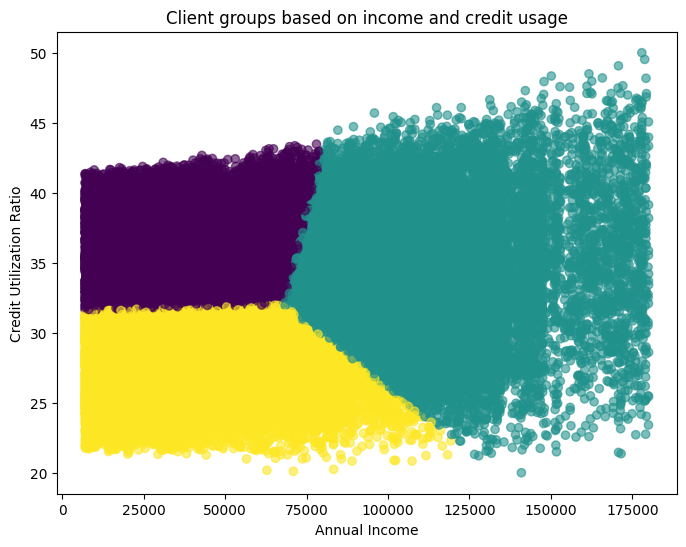

In [39]:
# scatterplot in original units
plt.figure(figsize=(8, 6))
plt.scatter(
    dataset["Annual_Income"],
    dataset["Credit_Utilization_Ratio"],
    c=dataset["cluster"],
    alpha=0.6
)

plt.xlabel("Annual Income")
plt.ylabel("Credit Utilization Ratio")
plt.title("Client groups based on income and credit usage")
plt.show()